<a href="https://colab.research.google.com/github/niva1303-droid/Social-Media-Engagement-Analytics-Using-Python/blob/main/Python_for_DA_Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Social Media Engagement Analytics Using Python**

**Task 1 — Data Import & Setup**

○ Import CSV using Pandas

○ Check/convert data types

○ Convert date columns to datetime

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()


Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [3]:
df = pd.read_csv("social_media_engagement_5000.csv")

In [4]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [5]:
df.shape

(5000, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [7]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [8]:
df['posted_at'] = pd.to_datetime(df['posted_at'],errors = "coerce")

/tmp/ipykernel_5632/1073329078.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'],errors = "coerce")


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

#**Task 2 — Data Cleaning**

● Cleaning Missing Data

  ■ Detect missing values (isnull(), isna())

  ■ Handle using: dropna(), fillna(), median/mode, forward/backward-fill

In [10]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [11]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


age          150
gender       150
likes        150
comments     150
shares       150
sentiment    150
dtype: int64


In [12]:
missing_percentage = (missing_values / len(df)) * 100
print(missing_percentage[missing_percentage > 0])

age          3.0
gender       3.0
likes        3.0
comments     3.0
shares       3.0
sentiment    3.0
dtype: float64


In [13]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [14]:
df["age"] = df["age"].fillna(df["age"].median())

In [15]:
df["gender"].value_counts(dropna=False)

,count
gender,
Male,1699
Other,1581
Female,1570
NaN,150


In [16]:
df["gender"] = df["gender"].fillna("Unknown")

In [17]:
df["gender"].value_counts(dropna=False)

,count
gender,
Male,1699
Other,1581
Female,1570
Unknown,150


In [18]:
df[["likes", "comments", "shares"]].describe()

,likes,comments,shares
count,4850.000000,4850.000000,4850.000000
mean,10107.043711,1502.195670,1002.629485
std,5789.819252,869.537889,579.615158
min,10.000000,0.000000,0.000000
25%,5068.500000,760.000000,498.000000
50%,10105.500000,1497.000000,1012.000000
75%,15115.000000,2256.000000,1501.000000
max,19998.000000,2999.000000,1999.000000


In [19]:
engagement_columns = ["likes", "comments", "shares"]

for col in engagement_columns:
    df[col] = df[col].fillna(df[col].median())

In [20]:
df[["likes", "comments", "shares"]].isnull().sum()

,0
likes,0
comments,0
shares,0


In [21]:
df["sentiment"].value_counts(dropna=False)

,count
sentiment,
positive,2363
neutral,1527
negative,960
NaN,150


In [22]:
df["sentiment"] = df["sentiment"].fillna(
    df["sentiment"].mode()[0]
)

In [23]:
df["sentiment"].value_counts(dropna=False)

,count
sentiment,
positive,2513
neutral,1527
negative,960


In [24]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [25]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Rows: ", duplicate_count)

Number of Duplicate Rows:  0


**Data Formatting**

■ Fix incorrect data types

■ Standardize categories (e.g., gender labels)

■ Correct unrealistic values in likes, comments, shares

In [26]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [27]:
df["age"] = df["age"].astype(int)

df[["likes", "comments", "shares"]] = (
    df[["likes", "comments", "shares"]].astype(int)
)

In [28]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [29]:
categorical_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


gender:
gender
Male       1699
Other      1581
Female     1570
Unknown     150
Name: count, dtype: int64

country:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

post_type:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

post_category:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

device_type:
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

sentiment:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [30]:
columns_to_standardize = [
    "gender",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for col in columns_to_standardize:
    df[col] = df[col].str.strip().str.title()

# Remove accidental spaces from country
df["country"] = df["country"].str.strip()

In [31]:
for col in columns_to_standardize:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Male       1699
Other      1581
Female     1570
Unknown     150
Name: count, dtype: int64

post_type:
post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64

post_category:
post_category
Fitness      675
Tech         665
Music        635
Education    631
Lifestyle    607
Travel       600
Fashion      594
Food         593
Name: count, dtype: int64

device_type:
device_type
Mobile     1684
Tablet     1658
Desktop    1658
Name: count, dtype: int64

sentiment:
sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64


In [32]:
print("Negative Likes:", (df["likes"] < 0).sum())
print("Negative Comments:", (df["comments"] < 0).sum())
print("Negative Shares:", (df["shares"] < 0).sum())

Negative Likes: 0
Negative Comments: 0
Negative Shares: 0


In [33]:
df[["likes", "comments", "shares"]].agg(["min", "max"])

,likes,comments,shares
min,10,0,0
max,19998,2999,1999


In [34]:
columns = ["likes", "comments", "shares"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}:")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print()

likes:
Lower Bound: -9351.0
Upper Bound: 29545.0
Number of Outliers: 0

comments:
Lower Bound: -1372.875
Upper Bound: 4400.125
Number of Outliers: 0

shares:
Lower Bound: -947.0
Upper Bound: 2941.0
Number of Outliers: 0



**● Feature Cleaning**

■ Extract hashtag count

■ Clean sentiment labels

In [35]:
df["hashtags"].head(10)

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel
5,#fitness
6,#music
7,#travel #music #fitness
8,#music #fun #fitness
9,#lifestyle #love


In [36]:
df["hashtags"].value_counts()

,count
hashtags,
#tech,201
#love,176
#fitness,174
#music,165
#fun,163
...,...
#fun #foodie #reels,1
#love #tech #music,1
#love #lifestyle #tech,1


In [37]:
df["hashtag_count"] = df["hashtags"].str.count(r"#")

In [38]:
df[["hashtags", "hashtag_count"]].head(10)

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


In [39]:
df["hashtag_count"].value_counts().sort_index()

,count
hashtag_count,
1,1655
2,1697
3,1648


In [40]:
df["hashtag_count"].describe()

,hashtag_count
count,5000.000000
mean,1.998600
std,0.812853
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,3.000000


In [41]:
df["sentiment"] = (
    df["sentiment"]
    .str.strip()
    .str.title()
)

In [42]:
df["sentiment"].value_counts()

,count
sentiment,
Positive,2513
Neutral,1527
Negative,960


In [43]:
df[["hashtags", "hashtag_count"]].head(10)

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
5,#fitness,1
6,#music,1
7,#travel #music #fitness,3
8,#music #fun #fitness,3
9,#lifestyle #love,2


#**Task 3 — Data Exploration using Pandas**

Perform the following:

● View dataset structure using head(), tail(), shape, and columns.

● Check data types and info with info() and dtypes.

● Generate summary statistics using describe().

● Analyze categorical distributions using value_counts(), unique(), and nunique().

● Create a correlation matrix for numeric fields.

● Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country)

In [44]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,Text,Food,4862,344,955,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,Image,Fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1


In [45]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,Video,Education,16210,2013,1837,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,Reel,Education,16924,2734,1583,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,Text,Travel,13487,1497,167,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,Video,Fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,Text,Travel,14830,503,1798,3743,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [46]:
df.shape

(5000, 20)

In [47]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 5000
Number of Columns: 20


In [48]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [50]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [51]:
df[
    [
        "age",
        "likes",
        "comments",
        "shares",
        "watch_time_sec",
        "impression_count",
        "follower_count",
        "engagement_rate",
        "hashtag_count"
    ]
].describe().round(2)

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,38.44,10106.98,1502.04,1002.91,4014.50,50013.73,393698.22,0.96,2.00
std,14.69,5702.29,856.39,570.86,2308.10,28844.94,230927.88,5.32,0.81
min,13.00,10.00,0.00,0.00,0.00,105.00,87.00,0.01,1.00
25%,26.00,5235.00,792.00,511.00,2017.75,24988.25,194480.00,0.15,1.00
50%,38.00,10105.00,1497.00,1012.00,4034.50,49934.50,388982.00,0.25,2.00
75%,51.00,14959.00,2235.25,1483.00,6020.25,74662.25,589744.25,0.50,3.00
max,64.00,19998.00,2999.00,1999.00,7998.00,99995.00,799533.00,191.50,3.00


In [53]:
categorical_columns = [
    "gender",
    "country",
    "post_type",
    "post_category",
    "device_type",
    "sentiment"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Male       1699
Other      1581
Female     1570
Unknown     150
Name: count, dtype: int64

country:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

post_type:
post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64

post_category:
post_category
Fitness      675
Tech         665
Music        635
Education    631
Lifestyle    607
Travel       600
Fashion      594
Food         593
Name: count, dtype: int64

device_type:
device_type
Mobile     1684
Tablet     1658
Desktop    1658
Name: count, dtype: int64

sentiment:
sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64


In [54]:
for col in categorical_columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male' 'Other' 'Unknown']
country: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
post_type: ['Image' 'Reel' 'Text' 'Video']
post_category: ['Fitness' 'Food' 'Tech' 'Travel' 'Fashion' 'Lifestyle' 'Education'
 'Music']
device_type: ['Mobile' 'Tablet' 'Desktop']
sentiment: ['Negative' 'Positive' 'Neutral']


In [55]:
df[categorical_columns].nunique()

,0
gender,4
country,10
post_type,4
post_category,8
device_type,3
sentiment,3


In [56]:
numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate",
    "hashtag_count"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(2)

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.00,-0.04,-0.01,0.01,0.01,0.01,-0.02,0.01,0.01
likes,-0.04,1.00,-0.02,0.00,0.01,0.01,-0.02,0.09,-0.00
comments,-0.01,-0.02,1.00,0.01,-0.02,-0.01,-0.01,0.00,-0.02
shares,0.01,0.00,0.01,1.00,0.01,-0.01,-0.01,0.02,0.01
watch_time_sec,0.01,0.01,-0.02,0.01,1.00,-0.00,0.00,-0.00,-0.02
impression_count,0.01,0.01,-0.01,-0.01,-0.00,1.00,-0.02,-0.23,-0.00
follower_count,-0.02,-0.02,-0.01,-0.01,0.00,-0.02,1.00,0.00,0.01
engagement_rate,0.01,0.09,0.00,0.02,-0.00,-0.23,0.00,1.00,0.01
hashtag_count,0.01,-0.00,-0.02,0.01,-0.02,-0.00,0.01,0.01,1.00


In [57]:
correlation_matrix["engagement_rate"].sort_values(
    ascending=False
)

,engagement_rate
engagement_rate,1.000000
likes,0.093521
shares,0.021724
age,0.008039
hashtag_count,0.005319
follower_count,0.002292
comments,0.000051
watch_time_sec,-0.001148
impression_count,-0.232226


In [58]:
avg_likes_by_post_type = (
    df.groupby("post_type")["likes"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

avg_likes_by_post_type

,likes
post_type,
Video,10188.59
Image,10104.85
Text,10100.13
Reel,10037.78


In [59]:
impressions_by_country = (
    df.groupby("country")["impression_count"]
      .sum()
      .sort_values(ascending=False)
)

impressions_by_country

,impression_count
country,
India,28067377
USA,25683200
France,25656926
UK,25201861
Canada,24984716
Brazil,24793360
UAE,24610992
Australia,23834767
Germany,23816649


In [61]:
#Average engagement rate by post type:

df.groupby("post_type")["engagement_rate"].mean().round(2).sort_values(
    ascending=False
)

,engagement_rate
post_type,
Video,1.12
Text,1.06
Image,0.90
Reel,0.78


In [62]:
# Average engagement by post category:

df.groupby("post_category")[
    ["likes", "comments", "shares", "engagement_rate"]
].mean().round(2)

,likes,comments,shares,engagement_rate
post_category,,,,
Education,10126.47,1455.34,996.45,0.84
Fashion,9843.34,1530.54,982.52,0.81
Fitness,9914.59,1501.14,1042.05,0.87
Food,10225.50,1510.88,1002.80,1.36
Lifestyle,10180.54,1467.84,991.14,1.09
Music,10205.74,1558.71,1024.09,0.89
Tech,10171.56,1505.55,1009.37,1.16
Travel,10196.29,1485.95,968.31,0.70


In [63]:
# Average engagement rate by sentiment:

df.groupby("sentiment")["engagement_rate"].mean().round(2).sort_values(
    ascending=False
)

,engagement_rate
sentiment,
Negative,1.04
Neutral,0.99
Positive,0.92


In [64]:
# Average engagement by device:

df.groupby("device_type")[
    ["likes", "comments", "shares"]
].mean().round(2)

,likes,comments,shares
device_type,,,
Desktop,10199.84,1498.63,1010.08
Mobile,10158.62,1511.07,993.49
Tablet,9961.67,1496.28,1005.31


In [65]:
# Hashtag count and engagement:

df.groupby("hashtag_count")[
    ["likes", "comments", "shares", "engagement_rate"]
].mean().round(2)

,likes,comments,shares,engagement_rate
hashtag_count,,,,
1,10075.31,1532.68,988.50,0.87
2,10198.65,1473.50,1012.74,1.08
3,10044.39,1500.65,1007.27,0.94


#**Task 4 — Data Wrangling**

● Use merge, concat, or join if combining DataFrames.

● Create new fields such as engagement_score, log-transformed metrics
(optional), and hashtag count.

● Perform groupby summaries by post_type, country, and sentiment.

In [66]:
df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

In [67]:
df[
    ["likes", "comments", "shares", "engagement_score"]
].head()

,likes,comments,shares,engagement_score
0,7011,354,1157,8522
1,11750,2606,1807,16163
2,4862,344,955,6161
3,5350,1083,1049,7482
4,12682,2735,1300,16717


In [68]:
df["engagement_score"].describe().round(2)

,engagement_score
count,5000.00
mean,12611.93
std,5782.06
min,193.00
25%,7807.00
50%,12551.50
75%,17478.25
max,24680.00


In [69]:
df[["hashtags", "hashtag_count"]].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [70]:
df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])

In [71]:
np.log1p(0)

np.float64(0.0)

In [72]:
df[
    [
        "likes", "log_likes",
        "comments", "log_comments",
        "shares", "log_shares"
    ]
].head()

,likes,log_likes,comments,log_comments,shares,log_shares
0,7011,8.855378,354,5.872118,1157,7.054450
1,11750,9.371694,2606,7.865955,1807,7.499977
2,4862,8.489411,344,5.843544,955,6.862758
3,5350,8.585039,1083,6.988413,1049,6.956545
4,12682,9.448018,2735,7.914252,1300,7.170888


In [73]:
post_type_summary = (
    df.groupby("post_type")
      .agg(
          total_posts=("post_id", "count"),
          avg_likes=("likes", "mean"),
          avg_comments=("comments", "mean"),
          avg_shares=("shares", "mean"),
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean")
      )
      .round(2)
      .sort_values("avg_engagement_score", ascending=False)
)

post_type_summary

,total_posts,avg_likes,avg_comments,avg_shares,avg_engagement_score,avg_engagement_rate
post_type,,,,,,
Video,1225,10188.59,1479.16,996.83,12664.58,1.12
Image,1247,10104.85,1525.24,1019.29,12649.38,0.90
Text,1245,10100.13,1499.11,1013.99,12613.23,1.06
Reel,1283,10037.78,1504.19,982.04,12524.01,0.78


In [74]:
country_summary = (
    df.groupby("country")
      .agg(
          total_posts=("post_id", "count"),
          total_impressions=("impression_count", "sum"),
          avg_impressions=("impression_count", "mean"),
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean")
      )
      .round(2)
      .sort_values("avg_engagement_score", ascending=False)
)

country_summary

,total_posts,total_impressions,avg_impressions,avg_engagement_score,avg_engagement_rate
country,,,,,
France,496,25656926,51727.67,12903.37,1.15
Australia,493,23834767,48346.38,12809.60,1.32
UAE,503,24610992,48928.41,12757.76,1.11
Germany,490,23816649,48605.41,12635.64,0.76
Canada,513,24984716,48703.15,12605.88,0.92
Japan,472,23418816,49616.14,12578.64,0.77
USA,501,25683200,51263.87,12575.45,0.58
India,535,28067377,52462.39,12492.68,0.66
Brazil,504,24793360,49193.17,12385.97,1.54


In [75]:
sentiment_summary = (
    df.groupby("sentiment")
      .agg(
          total_posts=("post_id", "count"),
          avg_likes=("likes", "mean"),
          avg_comments=("comments", "mean"),
          avg_shares=("shares", "mean"),
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean")
      )
      .round(2)
      .sort_values("avg_engagement_score", ascending=False)
)

sentiment_summary

,total_posts,avg_likes,avg_comments,avg_shares,avg_engagement_score,avg_engagement_rate
sentiment,,,,,,
Negative,960,10208.08,1516.09,1007.31,12731.48,1.04
Positive,2513,10180.05,1480.65,1005.09,12665.78,0.92
Neutral,1527,9923.18,1528.40,996.57,12448.15,0.99


#** Task 5 — Statistical Analysis**

Compute descriptive stats for “likes, comments, shares, watch_time,
engagement_rate, followers” columns:

● Mean, median, mode

● Standard deviation, variance

● Percentiles

● (Optional) Skewness and kurtosis

In [78]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score', 'log_likes', 'log_comments',
       'log_shares'],
      dtype='object')

In [79]:
stat_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

In [80]:
df[stat_columns].mean().round(2)

,0
likes,10106.98
comments,1502.04
shares,1002.91
watch_time_sec,4014.50
engagement_rate,0.96
follower_count,393698.22


In [81]:
df[stat_columns].median().round(2)

,0
likes,10105.00
comments,1497.00
shares,1012.00
watch_time_sec,4034.50
engagement_rate,0.25
follower_count,388982.00


In [83]:
df[stat_columns].mode().iloc[0]

,0
likes,10105.000000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [84]:
df[stat_columns].std().round(2)

,0
likes,5702.29
comments,856.39
shares,570.86
watch_time_sec,2308.10
engagement_rate,5.32
follower_count,230927.88


In [85]:
df[stat_columns].var().round(2)

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828000e+01
follower_count,5.332769e+10


In [86]:
df[stat_columns].quantile(
    [0.25, 0.50, 0.75]
).round(2)

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.15,194480.00
0.50,10105.0,1497.00,1012.0,4034.50,0.25,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.50,589744.25


In [87]:
df[stat_columns].skew().round(2)

,0
likes,-0.01
comments,0.00
shares,-0.01
watch_time_sec,-0.02
engagement_rate,18.78
follower_count,0.04


In [88]:
df[stat_columns].kurt().round(2)

,0
likes,-1.15
comments,-1.14
shares,-1.15
watch_time_sec,-1.20
engagement_rate,482.99
follower_count,-1.19


In [89]:
statistical_summary = pd.DataFrame({
    "Mean": df[stat_columns].mean(),
    "Median": df[stat_columns].median(),
    "Mode": df[stat_columns].mode().iloc[0],
    "Std Dev": df[stat_columns].std(),
    "Variance": df[stat_columns].var(),
    "25th Percentile": df[stat_columns].quantile(0.25),
    "50th Percentile": df[stat_columns].quantile(0.50),
    "75th Percentile": df[stat_columns].quantile(0.75),
    "Skewness": df[stat_columns].skew(),
    "Kurtosis": df[stat_columns].kurt()
})

statistical_summary.round(2)

,Mean,Median,Mode,Std Dev,Variance,25th Percentile,50th Percentile,75th Percentile,Skewness,Kurtosis
likes,10106.98,10105.00,10105.00,5702.29,3.251615e+07,5235.00,10105.00,14959.00,-0.01,-1.15
comments,1502.04,1497.00,1497.00,856.39,7.334095e+05,792.00,1497.00,2235.25,0.00,-1.14
shares,1002.91,1012.00,1012.00,570.86,3.258757e+05,511.00,1012.00,1483.00,-0.01,-1.15
watch_time_sec,4014.50,4034.50,916.00,2308.10,5.327309e+06,2017.75,4034.50,6020.25,-0.02,-1.20
engagement_rate,0.96,0.25,0.01,5.32,2.828000e+01,0.15,0.25,0.50,18.78,482.99
follower_count,393698.22,388982.00,497502.00,230927.88,5.332769e+10,194480.00,388982.00,589744.25,0.04,-1.19


# **Task 6 — Data Visualization (Min. 8 Plots Required)**


**● Matplotlib**

○ Scatter: likes vs impressions

○ Line: daily engagement trend

○ Bar: posts by category

○ Pie: gender distribution

○ Histogram: age

○ Box: engagement rate

In [90]:
import matplotlib.pyplot as plt

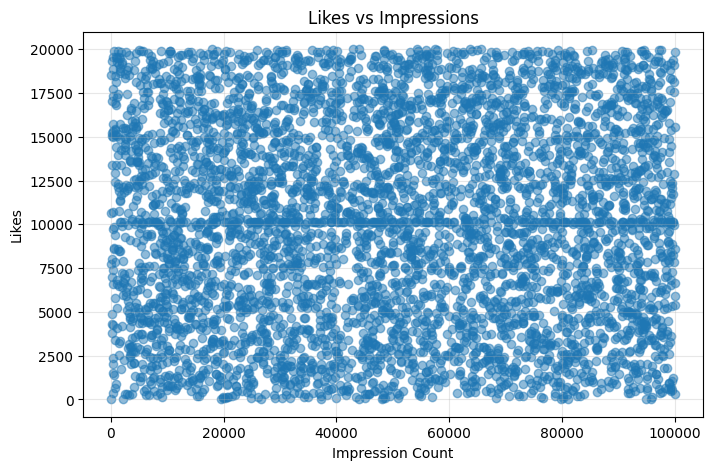

In [91]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["impression_count"],
    df["likes"],
    alpha=0.5
)

plt.title("Likes vs Impressions")
plt.xlabel("Impression Count")
plt.ylabel("Likes")
plt.grid(alpha=0.3)
plt.show()

In [92]:
df["likes"].corr(df["impression_count"])

np.float64(0.007951938410158236)

In [93]:
daily_engagement = (
    df.groupby(df["posted_at"].dt.date)["engagement_score"]
      .sum()
)

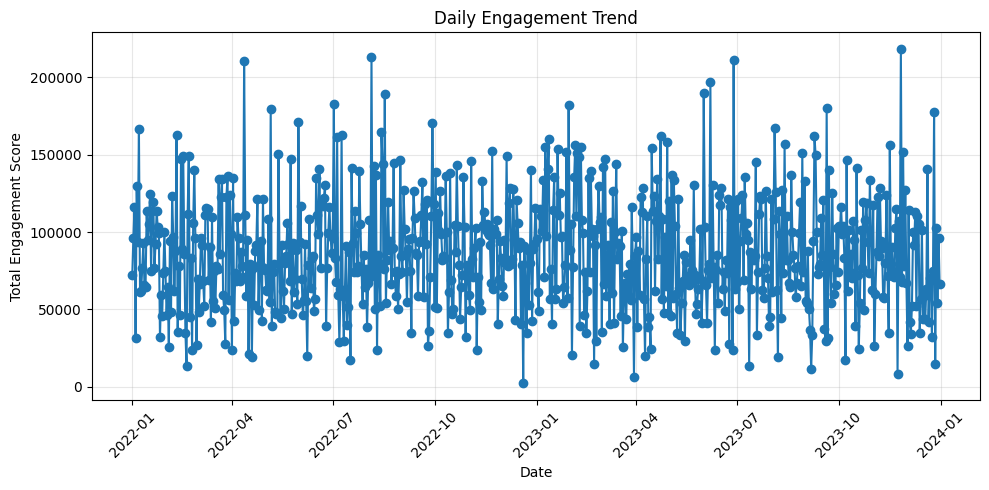

In [94]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_engagement.index,
    daily_engagement.values,
    marker="o"
)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Total Engagement Score")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

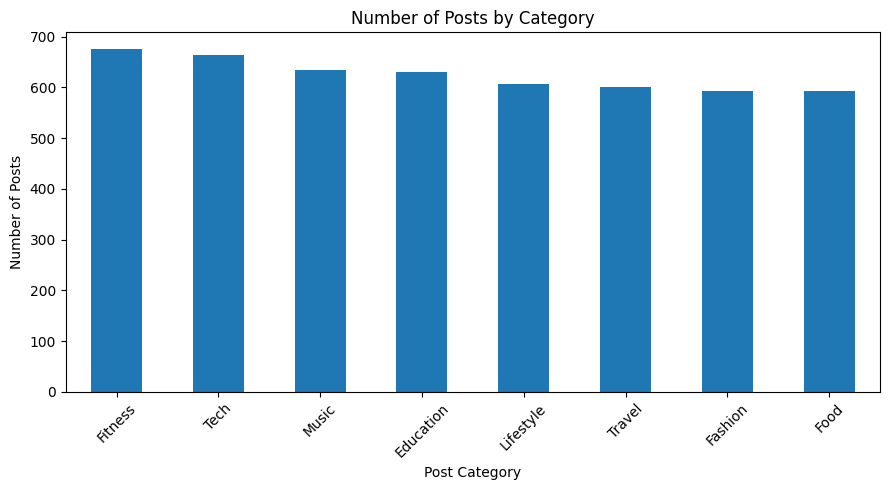

In [95]:
posts_by_category = df["post_category"].value_counts()

plt.figure(figsize=(9, 5))

posts_by_category.plot(kind="bar")

plt.title("Number of Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

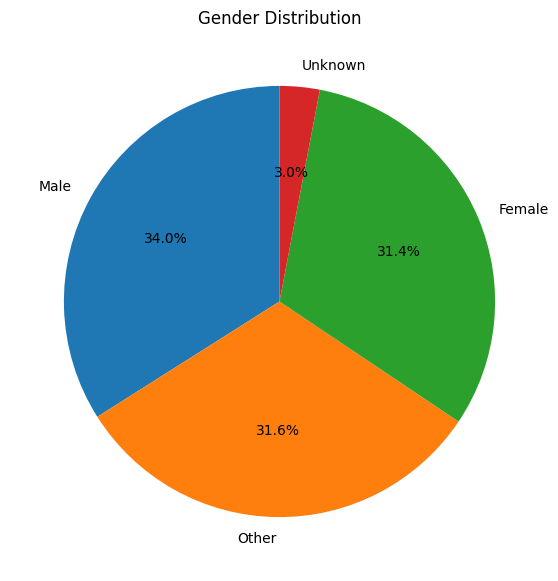

In [96]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

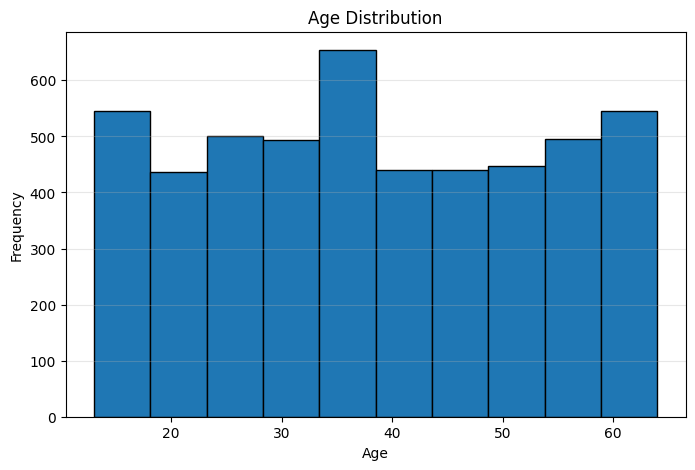

In [97]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["age"],
    bins=10,
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [98]:
df["age"].describe()

,age
count,5000.000000
mean,38.440400
std,14.687151
min,13.000000
25%,26.000000
50%,38.000000
75%,51.000000
max,64.000000


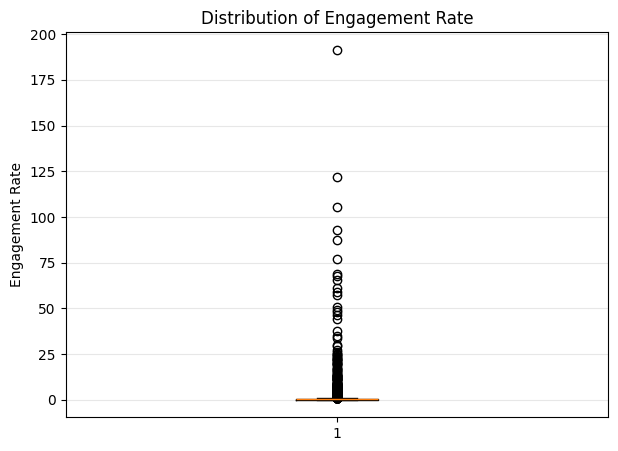

In [99]:
plt.figure(figsize=(7, 5))

plt.boxplot(df["engagement_rate"])

plt.title("Distribution of Engagement Rate")
plt.ylabel("Engagement Rate")
plt.grid(axis="y", alpha=0.3)
plt.show()

**● Seaborn**

○ Count plot: post type

○ Bar plot: avg likes by category

○ Violin: followers vs sentiment

○ Pair plot: numeric features

○ Heatmap: correlation matrix

○ Swarm plot: engagement vs device

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

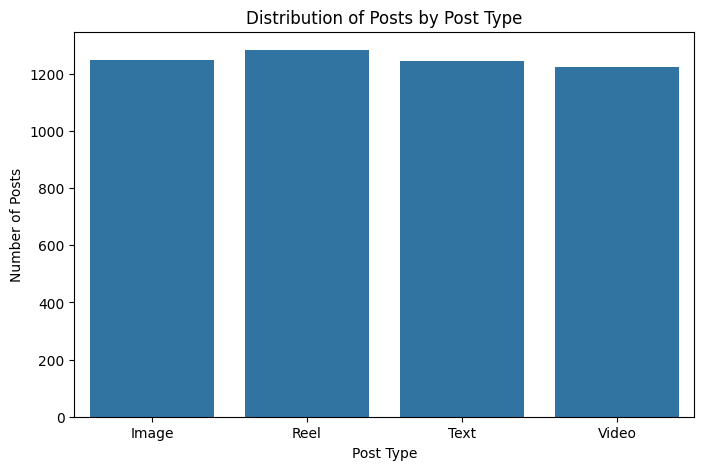

In [101]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="post_type"
)

plt.title("Distribution of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.show()

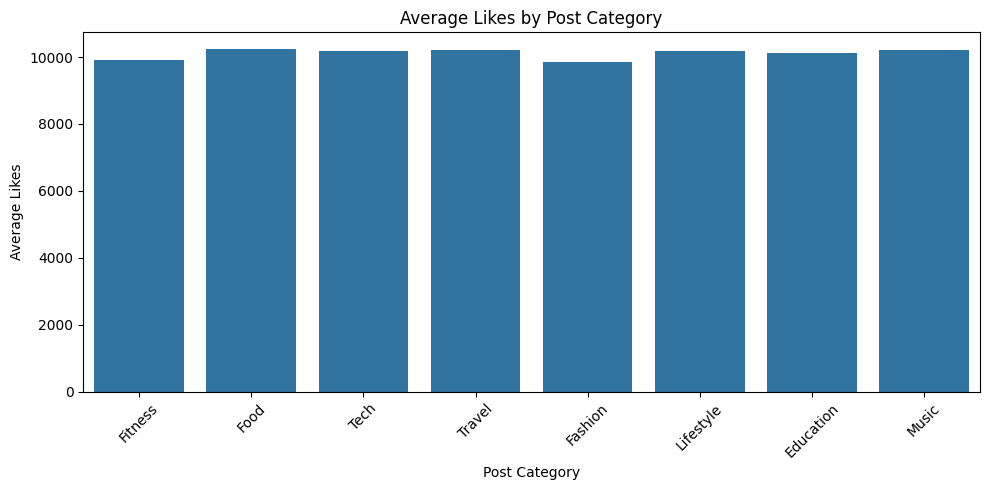

In [103]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    errorbar=None
)

plt.title("Average Likes by Post Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

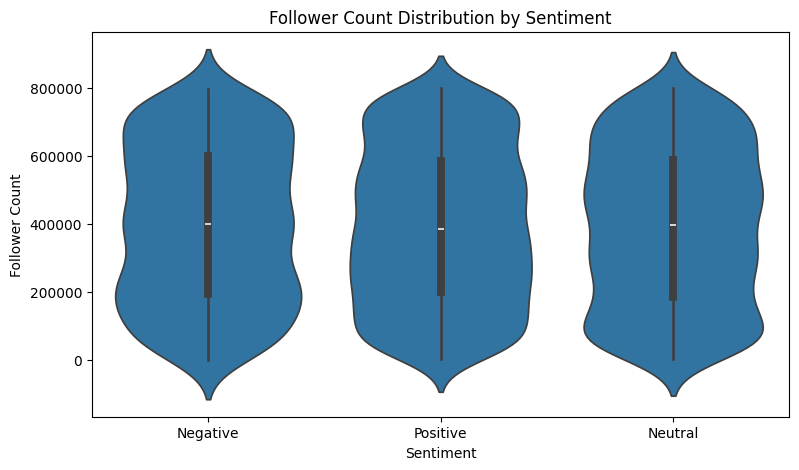

In [104]:
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Follower Count Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.show()

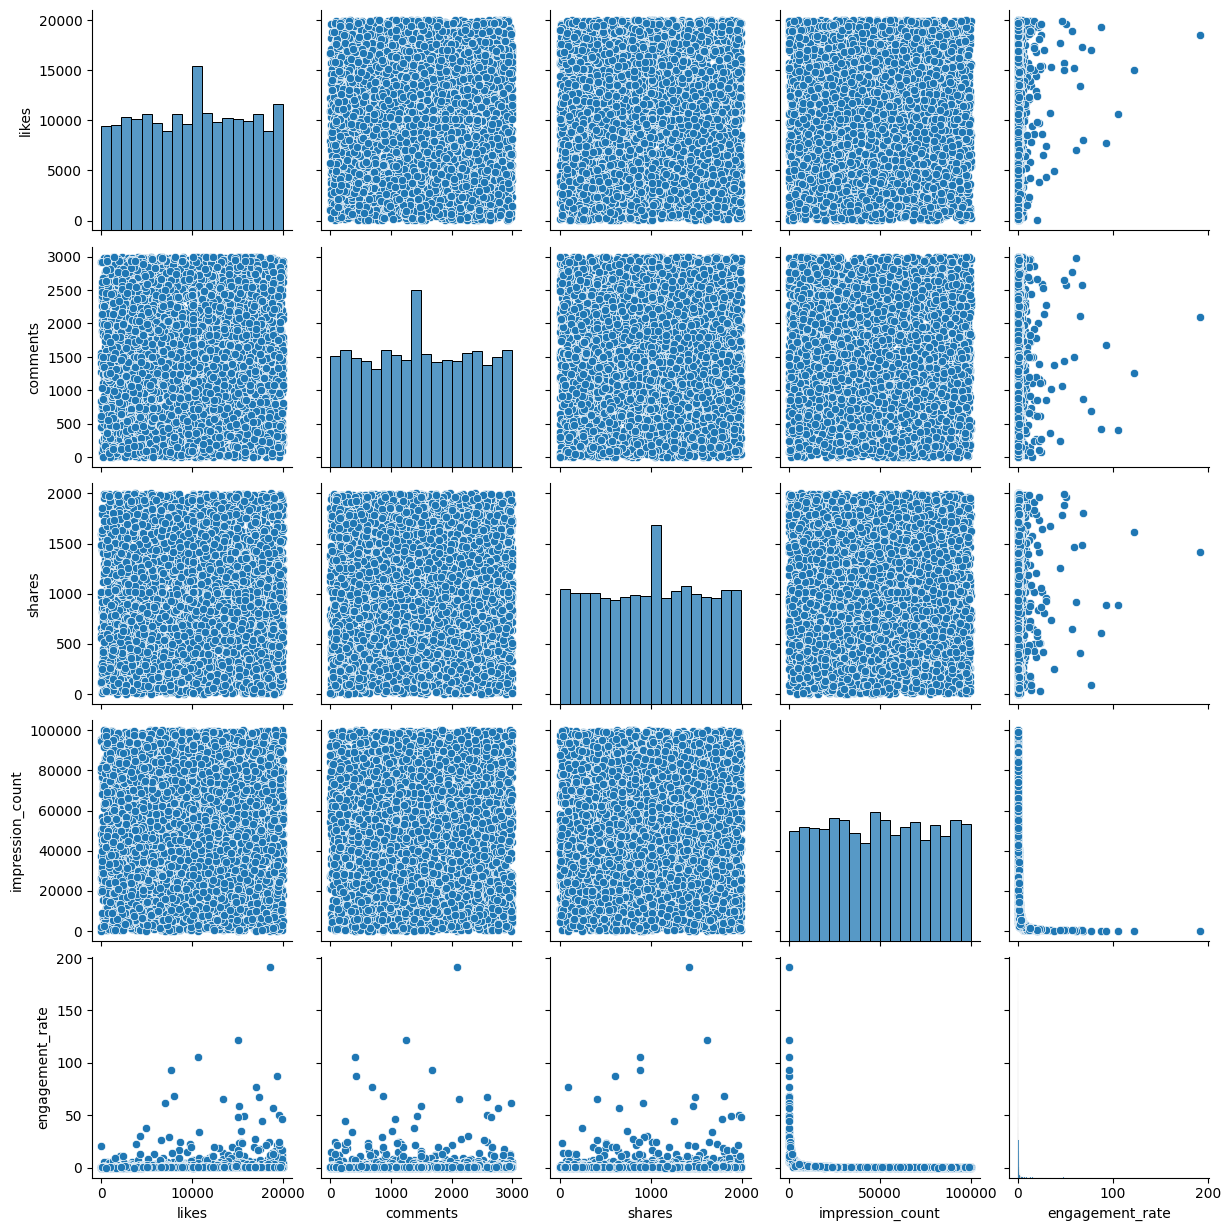

In [105]:
pairplot_columns = [
    "likes",
    "comments",
    "shares",
    "impression_count",
    "engagement_rate"
]

sns.pairplot(
    df[pairplot_columns],
    diag_kind="hist"
)

plt.show()

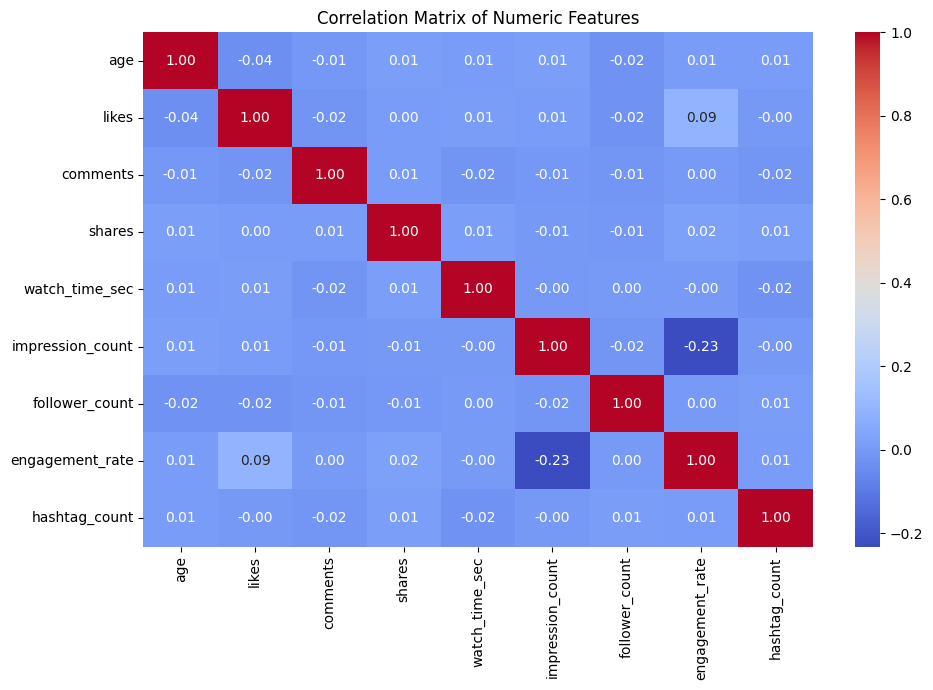

In [106]:
numeric_columns = [
    "age",
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate",
    "hashtag_count"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

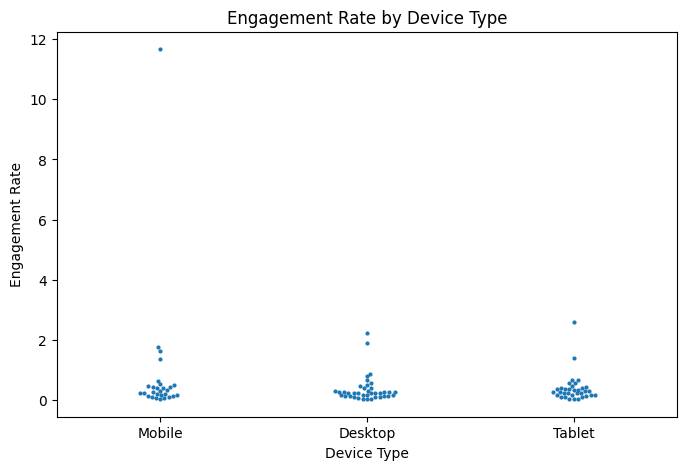

In [109]:
sample_df = df.sample(
    n=min(100, len(df)),
    random_state=42
)

plt.figure(figsize=(8, 5))

sns.swarmplot(
    data=sample_df,
    x="device_type",
    y="engagement_rate",
    size=3
)

plt.title("Engagement Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.show()

#**Plotly (Interactive)**

○ Interactive line chart/bar chart/bubble/scatter chart

In [110]:
import plotly.express as px

In [111]:
daily_engagement = (
    df.groupby(df["posted_at"].dt.date)["engagement_score"]
      .sum()
      .reset_index()
)

daily_engagement.columns = ["Date", "Total Engagement"]

fig = px.line(
    daily_engagement,
    x="Date",
    y="Total Engagement",
    markers=True,
    title="Daily Engagement Trend"
)

fig.show()

In [112]:
avg_likes_category = (
    df.groupby("post_category")["likes"]
      .mean()
      .round(2)
      .reset_index()
      .sort_values("likes", ascending=False)
)

In [113]:
fig = px.bar(
    avg_likes_category,
    x="post_category",
    y="likes",
    title="Average Likes by Post Category",
    labels={
        "post_category": "Post Category",
        "likes": "Average Likes"
    }
)

fig.show()

In [114]:
plotly_sample = df.sample(
    n=min(1000, len(df)),
    random_state=42
)

In [115]:
fig = px.scatter(
    plotly_sample,
    x="impression_count",
    y="likes",
    size="follower_count",
    color="post_type",
    hover_data=[
        "post_category",
        "sentiment",
        "engagement_rate"
    ],
    title="Likes vs Impressions by Post Type",
    labels={
        "impression_count": "Impressions",
        "likes": "Likes",
        "post_type": "Post Type"
    }
)

fig.show()

#**Final Insights should include the following analysis:**

**● Content Performance**

○ Which post types have the highest engagement?

○ Best-performing content category?

○ Which countries have the highest average engagement rate?


In [116]:
post_type_performance = (
    df.groupby("post_type")
      .agg(
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean"),
          avg_likes=("likes", "mean"),
          avg_comments=("comments", "mean"),
          avg_shares=("shares", "mean")
      )
      .round(2)
      .sort_values("avg_engagement_score", ascending=False)
)

post_type_performance

,avg_engagement_score,avg_engagement_rate,avg_likes,avg_comments,avg_shares
post_type,,,,,
Video,12664.58,1.12,10188.59,1479.16,996.83
Image,12649.38,0.90,10104.85,1525.24,1019.29
Text,12613.23,1.06,10100.13,1499.11,1013.99
Reel,12524.01,0.78,10037.78,1504.19,982.04


In [117]:
category_performance = (
    df.groupby("post_category")
      .agg(
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean"),
          avg_likes=("likes", "mean")
      )
      .round(2)
      .sort_values("avg_engagement_score", ascending=False)
)

category_performance

,avg_engagement_score,avg_engagement_rate,avg_likes
post_category,,,
Music,12788.54,0.89,10205.74
Food,12739.18,1.36,10225.50
Tech,12686.48,1.16,10171.56
Travel,12650.54,0.70,10196.29
Lifestyle,12639.52,1.09,10180.54
Education,12578.26,0.84,10126.47
Fitness,12457.78,0.87,9914.59
Fashion,12356.41,0.81,9843.34


In [118]:
country_engagement = (
    df.groupby("country")["engagement_rate"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

country_engagement.head()

,engagement_rate
country,
Brazil,1.54
Australia,1.32
France,1.15
UAE,1.11
Canada,0.92


**● User Trends**

○ How age affects engagement

○ Performance difference for verified accounts

In [119]:
age_correlation = df["age"].corr(df["engagement_rate"])

print(
    "Correlation between Age and Engagement Rate:",
    round(age_correlation, 3)
)

Correlation between Age and Engagement Rate: 0.008


In [120]:
age_bins = [0, 18, 25, 35, 45, 55, float("inf")]
age_labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [121]:
age_engagement = (
    df.groupby(
        "age_group",
        observed=True
    )["engagement_rate"]
      .mean()
      .round(2)
)

age_engagement

,engagement_rate
age_group,
Under 18,0.86
18-25,1.04
26-35,0.81
36-45,0.96
46-55,1.21
56+,0.90


In [122]:
verified_performance = (
    df.groupby("is_verified")
      .agg(
          avg_likes=("likes", "mean"),
          avg_comments=("comments", "mean"),
          avg_shares=("shares", "mean"),
          avg_impressions=("impression_count", "mean"),
          avg_watch_time=("watch_time_sec", "mean"),
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean")
      )
      .round(2)
)

verified_performance

# False = Non-Verified and True  = Verified

,avg_likes,avg_comments,avg_shares,avg_impressions,avg_watch_time,avg_engagement_score,avg_engagement_rate
is_verified,,,,,,,
False,10137.19,1505.51,1001.60,49935.29,4005.20,12644.30,0.95
True,9824.52,1469.57,1015.17,50747.34,4101.49,12309.27,1.05


**● Behavioral Insights**

○ Best time of day for impressions

○ Device type impact on watch time

In [123]:
df["post_hour"] = df["posted_at"].dt.hour

In [124]:
hourly_impressions = (
    df.groupby("post_hour")["impression_count"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

hourly_impressions

,impression_count
post_hour,
0,50013.73


In [126]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_of_day"] = df["post_hour"].apply(time_of_day)

In [127]:
time_performance = (
    df.groupby("time_of_day")["impression_count"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

time_performance

,impression_count
time_of_day,
Night,50013.73


In [128]:
device_watch_time = (
    df.groupby("device_type")["watch_time_sec"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

device_watch_time

,watch_time_sec
device_type,
Mobile,4087.83
Tablet,3979.74
Desktop,3974.79


**● Sentiment Analysis**

○ Which sentiment performs best

○ Behavior of negative/neutral sentiment posts

In [129]:
sentiment_performance = (
    df.groupby("sentiment")
      .agg(
          total_posts=("post_id", "count"),
          avg_likes=("likes", "mean"),
          avg_comments=("comments", "mean"),
          avg_shares=("shares", "mean"),
          avg_impressions=("impression_count", "mean"),
          avg_watch_time=("watch_time_sec", "mean"),
          avg_engagement_score=("engagement_score", "mean"),
          avg_engagement_rate=("engagement_rate", "mean")
      )
      .round(2)
      .sort_values("avg_engagement_score", ascending=False)
)

sentiment_performance

,total_posts,avg_likes,avg_comments,avg_shares,avg_impressions,avg_watch_time,avg_engagement_score,avg_engagement_rate
sentiment,,,,,,,,
Negative,960,10208.08,1516.09,1007.31,50191.96,4054.64,12731.48,1.04
Positive,2513,10180.05,1480.65,1005.09,50248.11,3988.65,12665.78,0.92
Neutral,1527,9923.18,1528.40,996.57,49515.97,4031.82,12448.15,0.99


In [130]:
negative_neutral = df[
    df["sentiment"].isin(["Negative", "Neutral"])
]

In [131]:
negative_neutral_summary = (
    negative_neutral.groupby("sentiment")
      .agg(
          total_posts=("post_id", "count"),
          avg_likes=("likes", "mean"),
          avg_comments=("comments", "mean"),
          avg_shares=("shares", "mean"),
          avg_impressions=("impression_count", "mean"),
          avg_watch_time=("watch_time_sec", "mean"),
          avg_engagement_rate=("engagement_rate", "mean")
      )
      .round(2)
)

negative_neutral_summary

,total_posts,avg_likes,avg_comments,avg_shares,avg_impressions,avg_watch_time,avg_engagement_rate
sentiment,,,,,,,
Negative,960,10208.08,1516.09,1007.31,50191.96,4054.64,1.04
Neutral,1527,9923.18,1528.40,996.57,49515.97,4031.82,0.99


#**Final Insights**

**1. Content Performance**

**Post Type Performance:** Video posts achieved the highest average engagement score at 12,664.58, followed closely by Image (12,649.38) and Text (12,613.23). Video also recorded the highest average engagement rate at 1.12, making it the strongest overall post type. Reels had the lowest average engagement score (12,524.01) and engagement rate (0.78).

**Content Category Performance:** Music generated the highest average engagement score (12,788.54), while Food recorded the highest average engagement rate (1.36) and the highest average likes (10,225.50). Therefore, Music leads in total interactions, whereas Food performs best relative to engagement rate.

**Country Performance:** Brazil had the highest average engagement rate at 1.54, followed by Australia (1.32), France (1.15), UAE (1.11), and Canada (0.92). This indicates that posts associated with Brazil generated the strongest average engagement rate among the countries analyzed.

**2. User Trends**

**Age and Engagement:** The 46–55 age group recorded the highest average engagement rate (1.21), followed by the 18–25 group (1.04). The 26–35 group had the lowest average rate (0.81). However, age-group averages alone do not prove that engagement increases with age. Your separate age_correlation result is needed to state the overall strength/direction of the age-engagement relationship.

**Verified vs Non-Verified Accounts:** Verified accounts achieved a slightly higher average engagement rate (1.05 vs 0.95) and higher average impressions (50,747.34 vs 49,935.29). However, non-verified accounts generated more average likes (10,137.19 vs 9,824.52) and a higher average engagement score (12,644.30 vs 12,309.27). This suggests verification does not consistently result in stronger performance across all engagement measures.

**3. Behavioral Insights**

**Best Time for Impressions:** 12:00 AM (hour 0) recorded the highest average impression count at 50,013.73, placing the strongest observed performance in the Night period. However, your pasted time_of_day output only shows Night, so I would avoid claiming Night outperformed Morning/Afternoon/Evening unless your complete grouped output confirms it.

**Device and Watch Time:** Mobile users recorded the highest average watch time at 4,087.83 seconds, compared with Tablet (3,979.74 seconds) and Desktop (3,974.79 seconds). Mobile therefore shows the strongest viewing-duration performance, although the differences between devices are relatively modest.

**4. Sentiment Analysis**

**Best-Performing Sentiment:** Interestingly, Negative posts generated the highest average engagement score (12,731.48) and engagement rate (1.04), despite representing only 960 posts. Positive posts were much more common (2,513 posts) but had a lower average engagement rate of 0.92. This shows that the most common sentiment was not necessarily the most engaging.

**Negative vs Neutral Behavior:** Negative posts received higher average likes (10,208.08 vs 9,923.18), shares (1,007.31 vs 996.57), impressions (50,191.96 vs 49,515.97), watch time (4,054.64 vs 4,031.82), and engagement rate (1.04 vs 0.99) than Neutral posts. However, Neutral posts generated slightly more average comments (1,528.40 vs 1,516.09). This suggests Negative content produced stronger overall engagement, while Neutral content encouraged slightly more commenting.

# **Overall Conclusion**

The analysis shows that Video content performs strongest among post types, while Music leads in total engagement among content categories and Food leads in engagement rate. Brazil shows the highest average engagement rate geographically. Verified accounts perform better on engagement rate and impressions but do not dominate all interaction metrics. Mobile users show the highest watch time, and Negative sentiment unexpectedly produces stronger overall engagement than Positive and Neutral content.